# Skeleton-of-Thought

1. **Skeleton Stage**：拆解問題的主要框架或骨架。
2. **Point-expanding Stage**：進一步擴展每個骨架的具體細節。
將前一日的新聞資料依據 Skeleton Stage 拆解的每個判斷依據都做一次判斷隔日漲跌  
e.g. 20230104的新聞判斷漲跌後存在20230105  
儲存格式：  
20230105  
判斷依據1: 由20230104的新聞判斷為漲  
判斷依據2: 由20230104的新聞判斷為跌  
...  


檔案說明：  
存在 out_twii/sot  


In [35]:
import os
import textwrap
import math
import pandas as pd
import numpy as np

from datetime import datetime
from dateutil.relativedelta import relativedelta

import google.generativeai as genai
from langchain.schema.messages import AIMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI
from google.generativeai.types import HarmBlockThreshold
from google.ai.generativelanguage_v1 import HarmCategory

from IPython.display import display
from IPython.display import Markdown

from collections import Counter

model = 'gemini-1.5-pro'
temperature = 1
top_p = 0.9
seed = 0

def to_markdown(text):
  text = text.replace('•', '  *')
  return Markdown(textwrap.indent(text, '> ', predicate=lambda _: True))

llm = ChatGoogleGenerativeAI(
                google_api_key = os.getenv('GEMINI_API_KEY'),
                model=model,
                temperature=temperature,
                top_p=top_p,
                seed=seed,
                safety_settings={
                        HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT: HarmBlockThreshold.BLOCK_NONE,
                        HarmCategory.HARM_CATEGORY_HARASSMENT: HarmBlockThreshold.BLOCK_NONE,
                        HarmCategory.HARM_CATEGORY_HATE_SPEECH: HarmBlockThreshold.BLOCK_NONE,
                        HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT : HarmBlockThreshold.BLOCK_NONE,
                
            })

# path_price = os.path.join(os.path.abspath(os.path.dirname(os.getcwd())), 'history_data', 'tw', 'stock_price', id + 'tech.csv')
# path_news_title = os.path.dirname(os.path.abspath(os.getcwd())) + "/history_data/tw/news_title/" + id + "news_title.json"
path_out = "out_twii/GA_sot/"
path_price = os.path.dirname(os.path.abspath(os.getcwd())) + "/history_data/tw/twii_history.csv"

In [36]:
import pandas as pd
import json
import os
from datetime import datetime, timedelta

def print_news(st, et, path_price):
    stock_ids = ['2308', '2317', '2330', '2382', '2412', '2454', '2881', '2882', '2891', '6505']
    stock_names = ['台達電', '鴻海', '台積電', '廣達', '中華電', '聯發科', '富邦金', '國泰金', '中信金', '台塑化']

    df_price_his = pd.read_csv(path_price, encoding='utf-8')
    df_price_his['日期'] = pd.to_datetime(df_price_his['日期'], format='%Y%m%d')
    df_price_his = df_price_his[(st <= df_price_his['日期']) & (df_price_his['日期'] <= et)]
    
    news = ''
    for index, row in df_price_his.iterrows():
        news_daily = ""
        for i in range(len(stock_ids)):
            stock_id = stock_ids[i]
            stock_name = stock_names[i]
            # print(stock_id, stock_name)
            path_news_title = os.path.dirname(os.path.abspath(os.getcwd())) + "/history_data/tw/news_title/" + stock_id + "news_title.json"
            
            news_date = row['日期']
            # print(news_date)
            
            with open(path_news_title, 'r', encoding='utf-8') as f:
                news_data = json.load(f)
                news_stock = ''
                for t in news_data[news_date.strftime('%Y%m%d')] :
                    # 刪掉t的換行符號
                    t = t.replace('\n', '')
                    # 刪除股價名稱還有
                    t = t.replace(stock_name, f'公司{i+1}')
                    news_stock += t + '、'
                    # 最後一個逗號刪掉
                    news_stock = news_stock[:-1]
                news_daily += f"公司{i+1}的新聞：{news_stock}；"
        
        news += f"{news_daily}\n"
    return news


start_day = datetime(2024, 1, 1)
end_day = datetime(2024, 1, 31)

# news = print_news(start_day, end_day, path_price)

# print(news)


# Skeleton Stage
建立骨架 Skeleton

In [37]:
# 定義策略元素字典，每個元素對應一個代號
# skeletons = {
#     "1": "台股重挫",
#     "2": "電子股跌勢",
#     "3": "台積電影響",
#     "4": "AI話題延燒",
#     "5": "聯發科賣壓",
#     "6": "政府補貼",
#     "7": "微星電競布局",
#     "8": "充電市場進軍",
#     "9": "新聞熱議",
#     "10": "航運撐盤",
#     "11": "電子逆勢",
#     "12": "台股新年跌",
#     "13": "法人動作",
#     "14": "蘋果供應鏈",
#     "15": "零件直供印度",
#     "16": "和碩合作",
#     "17": "公司擴展",
#     "18": "MIH展出",
#     "19": "電競技術應用",
#     "20": "ETF換血",
#     "21": "台塑營收預估",
#     "22": "ECFA影響",
#     "23": "外資賣超",
#     "24": "AI伺服器需求",
#     "25": "半導體市場",
#     "26": "鴻海電動車",
#     "27": "新能源技術",
#     "28": "金融股表現",
#     "29": "配息變動",
#     "30": "外資動態",
#     "31": "台積電法說會",
#     "32": "晶片短缺",
#     "33": "美中貿易戰影響",
#     "34": "原材料成本上升",
#     "35": "全球供應鏈瓶頸",
#     "36": "通膨壓力",
#     "37": "匯率波動",
#     "38": "能源價格上升",
#     "39": "歐盟碳關稅",
#     "40": "升息預期",
#     "41": "美元強勢",
#     "42": "台灣經濟成長率",
#     "43": "政府政策干預",
#     "44": "新創科技公司崛起",
#     "45": "全球疫情變化",
#     "46": "電動車市場需求",
#     "47": "半導體技術革新",
#     "48": "企業併購潮",
#     "49": "全球碳排放政策",
#     "50": "數位轉型推進",
#     "51": "新興市場投資潮",
#     "52": "市場避險情緒",
#     "53": "國際政治局勢",
#     "54": "供應鏈移轉至東南亞",
#     "55": "台股權值股波動",
#     "56": "科技股賣壓",
#     "57": "外匯存底變化",
#     "58": "財報季影響",
#     "59": "市場資金流向",
#     "60": "散戶投資動態"
# }

skeletons = {
    "E1": "利潤增長: 企業的利潤增長可以反映出其盈利能力的提升，吸引更多投資者。",
    "E2": "股價波動率: 股價的波動幅度能夠顯示市場對企業的短期反應和投資風險。",
    "E3": "市場情緒指標: 反映市場投資者的情緒，包括樂觀或悲觀，影響股票的交易活動。",
    "E4": "每日交易量: 交易量反映市場中對該股票的需求，交易量變化會影響股價走勢。",
    "E5": "市場趨勢追蹤: 追踪市場的總體趨勢，幫助預測個股在市場中的表現。",
    "E6": "財報發佈: 公司定期公佈的財務報告可以反映出企業的經營狀況，對股價有顯著影響。",
    "E7": "技術圖表分析: 通過技術指標和圖表模式來分析股票的潛在走勢，協助做出投資決策。",
    "E8": "價格移動平均線: 平滑短期價格波動，幫助判斷股票的中長期趨勢。",
    "E9": "公司內部管理調整: 內部管理的調整會影響企業的運營效率和員工士氣。",
    "E10": "風險管理措施: 有效的風險管理措施能降低市場波動對公司經營的負面影響。",
    "E11": "外匯匯率波動: 外匯匯率變動對國際企業的財務表現和市場評估產生直接影響。",
    "E12": "競爭者動作: 競爭對手的市場策略或行為變化可能直接影響公司股價表現。",
    "E13": "投資者情緒調查: 反映投資者對市場或公司未來表現的預期，對股價有指引作用。",
    "E14": "技術創新: 新技術的研發和應用能為企業帶來競爭優勢，推動業務增長。",
    "E15": "公司新聞發布: 公司相關的正面或負面新聞會快速影響市場對其的預期和股價波動。",
    "E16": "業內消息與謠言: 業內消息或謠言可能會影響市場對企業的認知，進而影響股價。",
    "E17": "政府政策變動: 政府政策的改變會對企業的經營環境和利潤產生重大影響。",
    "E18": "國際經濟事件影響: 全球性經濟事件如貿易戰或金融危機，會影響國際企業的表現。",
    "E19": "資金流入與流出: 資金流動狀況反映了市場對該企業未來走勢的信心和預期。",
    "E20": "股東回報政策: 穩定的股東回報政策能增加投資者的持股意願，推動股價穩定上升。",
    "E21": "銷售數據公佈: 銷售數據能反映公司產品需求狀況，對未來收益具有預示作用。",
    "E22": "市場需求波動: 市場對公司產品或服務的需求波動會直接影響其業績和股價表現。",
    "E23": "成本控制措施: 良好的成本控制可以提升利潤率，從而對股價有積極影響。",
    "E24": "競爭對手行為分析: 競爭對手的產品定價、行銷策略等變動會改變公司競爭格局。",
    "E25": "客戶需求變化: 客戶需求的快速變化會對公司產品策略和市場反應產生影響。",
    "E26": "價格調整策略: 公司的價格調整策略會影響其產品市場定位，從而影響銷售和收益。",
    "E27": "預測性財務數據: 預期的財務數據公佈可能會影響市場預期和股票交易活動。",
    "E28": "新產品推出時間點: 新產品推出的時間和效果會影響市場對企業未來增長的信心。",
    "E29": "供應鏈中斷: 供應鏈中斷會影響公司的生產能力和產品交付，進而影響股價。",
    "E30": "產品質量問題: 產品質量問題會損害公司聲譽，影響市場對其產品需求和股價。",
    "E31": "市場推廣活動: 有效的市場推廣活動能提高產品知名度，促進銷售和利潤增長。",
    "E32": "研發投入變動: 研發投入的變動會影響公司未來創新能力和市場競爭力。",
    "E33": "股息分配調整: 股息政策的調整會影響投資者的投資決策和市場對公司前景的看法。",
    "E34": "市場份額增減: 市場份額的變化反映了企業在行業中的競爭力和未來增長潛力。",
    "E35": "投資者信心波動: 投資者對公司未來表現的信心波動會直接反映在股價的波動上。",
    "E36": "行業競爭格局變化: 行業內的競爭格局變化會影響企業的市場定位和盈利能力。",
    "E37": "財務風險評估: 企業財務狀況的風險評估會影響投資者的持股意願和公司股價。",
    "E38": "合作夥伴變動: 與合作夥伴的關係變化會影響公司的市場策略和業務發展。",
    "E39": "社交媒體熱點: 社交媒體上的話題熱度可能會影響市場對公司的認知和股價波動。",
    "E40": "品牌推廣活動: 品牌推廣能提升公司產品的市場認知度，促進銷售和股價表現。",
    "E41": "市場認可度變動: 市場對公司產品或品牌的認可度變動，會影響銷售和投資者信心。",
    "E42": "投資者期望管理: 企業對投資者期望的管理能夠影響市場對公司未來表現的評估。",
    "E43": "財務報表修正: 財務報表的修正可能反映出之前數據的誤差，影響市場信心。",
    "E44": "價格競爭策略: 價格競爭策略的調整會影響企業的市場份額和利潤空間。",
    "E45": "行業趨勢變化: 行業趨勢的變化會影響公司未來的戰略和市場定位。",
    "E46": "原材料成本波動: 原材料價格的波動會影響公司的生產成本和利潤率。",
    "E47": "國際市場需求變化: 國際市場的需求變化會影響企業的出口和總體收入。",
    "E48": "科技應用變更: 科技應用的變更會提升企業的生產效率和市場應對能力。",
}

# Access by index using list of keys
key_list = list(skeletons.keys())
value_list = list(skeletons.values())

# Point-expanding Stage

In [38]:
# stock_ids = ['2308', '2317', '2330', '2382', '2412', '2454', '2881', '2882', '2891', '6505']
# path_price_his = os.path.dirname(os.path.abspath(os.getcwd())) + "/history_data/tw/twii_history.csv"
# st = datetime(2024, 4, 1)
# et = datetime(2024, 6, 30)

# # 讀取CSV檔案
# df_price_his = pd.read_csv(path_price_his, encoding='utf-8')
# df_price_his['日期'] = pd.to_datetime(df_price_his['日期'], format='%Y%m%d')
# df_price_his = df_price_his[(st <= df_price_his['日期']) & (df_price_his['日期'] <= et)]

# for i in range(len(df_price_his)):
#     # 取得前一日日期和新聞標題
#     news_date = df_price_his.iloc[i]['日期'] - timedelta(days=1)
#     text_news = "權值股的熱門新聞標題"
#     for j, stock_id in enumerate(stock_ids):
#         path_news_file = os.path.dirname(os.path.abspath(os.getcwd())) + "/history_data/tw/news_title/" + stock_id + "news_title.json"
#         with open(path_news_file, 'r', encoding='utf-8') as f:
#             news_data = json.load(f)
#             text_news += f"{news_data[news_date.strftime('%Y%m%d')]} \n"
#     print(text_news)

In [39]:
import time
import os
import json
import pandas as pd
from datetime import datetime, timedelta

def point_expanting(st, et, skeleton):
    stock_ids = ['2308', '2317', '2330', '2382', '2412', '2454', '2881', '2882', '2891', '6505']
    path_price_his = os.path.dirname(os.path.abspath(os.getcwd())) + "/history_data/tw/twii_history.csv"

    # 讀取CSV檔案
    df_price_his = pd.read_csv(path_price_his, encoding='utf-8')
    df_price_his['日期'] = pd.to_datetime(df_price_his['日期'], format='%Y%m%d')
    df_price_his = df_price_his[(st <= df_price_his['日期']) & (df_price_his['日期'] <= et)]

    # batch_size = 500
    output_data = {}  # 使用字典來存儲每一天的輸出數據

    for i in range(len(df_price_his)):
        # 取得前一日日期和新聞標題
        news_date = df_price_his.iloc[i]['日期'] - timedelta(days=1)
        text_news = "權值股的熱門新聞標題"
        for j, stock_id in enumerate(stock_ids):
            path_news_file = os.path.dirname(os.path.abspath(os.getcwd())) + "/history_data/tw/news_title/" + stock_id + "news_title.json"
            with open(path_news_file, 'r', encoding='utf-8') as f:
                news_data = json.load(f)
                text_news += f"{news_data[news_date.strftime('%Y%m%d')]} \n"
        # print(text_news)

        batch = []
        for skeleton in value_list:
            messages = [
            ("system", "你是一個厲害的金融領域專家"),
            ("human",
f"""
請對新聞根據{skeleton}為判斷以具，判斷隔日股票開盤買進收盤賣出的影響是正面的或負面的？
{text_news}

用以下格式回答，你只需要綜合所有的新聞給出一次的回答就好：
判斷結果: #yes/#no/#unknown 請盡量不要回答unknown
你的理由: **非常簡短**的用 1∼2 句話寫出來！
""")
                ]
            batch.append(messages)
        res = llm.batch(batch)

        date_str = df_price_his.iloc[i]['日期'].strftime('%Y%m%d')
        skeleton_res = {}
        for i in range(len(res)):
            sig = 0
            sig_str = res[i].content.split("你的理由")[0]
            if "unknown" in sig_str:
                sig = 0
            elif "yes" in sig_str:
                sig = 1
            elif "no" in sig_str:
                sig = -1

            skeleton_res[key_list[i]] = {
                "response" : res[i].content,
                "sig" : sig,
                "token": res[i].usage_metadata
            }
        
        output_data[date_str] = {
            "skeleton": skeleton_res,
        }

    # 將所有輸出數據寫入到同一個dictioanry中
    data = {
        "model": model,
        "temperature": temperature,
        "top_p": top_p,
        "seed": seed,
        "output_data": output_data,
    }
    
    return data

In [40]:
def save_data(folder_path, data):
    count = 1
    while True:
        if os.path.exists(folder_path + str(count) + ".json"):
            count += 1
            continue
        else:
            out_file = folder_path + str(count) + ".json"
            break
    json_content = json.dumps(data, ensure_ascii=False, indent=4)
    os.makedirs(os.path.dirname(out_file), exist_ok=True)
    with open(out_file, "w", encoding="UTF-8") as f:
        f.write(json_content)
    print(f"已儲存至{out_file}")
    return out_file

## generate content

In [41]:
stock_ids = ['2308', '2317', '2330', '2382', '2412', '2454', '2881', '2882', '2891', '6505']
st = datetime(2023, 7, 1)
et = datetime(2024, 9, 30)
data = point_expanting(st, et, skeletons)
save_data(path_out, data)


已儲存至out_twii/GA_sot/1.json


'out_twii/GA_sot/1.json'

In [8]:
# 合併兩個檔案的不同日期
def merge_data(path1, path2):
    with open(path1, 'r', encoding='utf-8') as f:
        data1 = json.load(f)
    with open(path2, 'r', encoding='utf-8') as f:
        data2 = json.load(f)
    
    data1['output_data'].update(data2['output_data'])
    return data1

# 輸出合併後的檔案
data3 = merge_data(path_out + '1.json', path_out + '2.json')
save_data(path_out, data3)


已儲存至out_twii/GA_sot/3.json


'out_twii/GA_sot/3.json'

# GA

## 評分

In [42]:
import pandas as pd
import json
import os

def eval(individual, data):
    # print(data)
    # 計算準確率和平均報酬率
    gain = []
    loss = []
    gain_precision = []
    loss_precision = []

    tp = 0
    fp = 0
    tn = 0
    fn = 0

    ttl_count = 0

    path_price_his = os.path.dirname(os.path.abspath(os.getcwd())) + "/history_data/tw/twii_history.csv"
    df_price_his = pd.read_csv(path_price_his, encoding='utf-8')
    df_price_his['日期'] = pd.to_datetime(df_price_his['日期'], format='%Y%m%d')

    for date_str, value in data.items():
        ttl_count += 1
        # print(date_str)
        # print(value)
        
        sigs = []
        sig = 0
        for i in range(len(individual)):

            if individual[i] == 1:
                # print(value['skeleton'][f'E{str(i+1)}']['sig'])
                sigs.append(value['skeleton'][f'E{str(i+1)}']['sig'])

            
        # 移除 sig 為 0 的元素
        sigs = list(filter(lambda a: a != 0, sigs))

        if len(sigs) > 0:
            # Count the frequency of each element
            count = Counter(sigs)

            # Get the maximum frequency
            max_count = max(count.values())

            # Get all elements with the maximum frequency
            most_frequent = [k for k, v in count.items() if v == max_count]

            # If there is a tie, set sig to 0; otherwise, set it to the most frequent element
            if len(most_frequent) > 1:
                sig = 0
            else:
                sig = most_frequent[0]

        df_price = df_price_his[df_price_his['日期'] == pd.to_datetime(date_str, format='%Y%m%d')]

        if df_price.empty:
            continue

        rtn = (df_price.iloc[0]['收盤指數'] - df_price.iloc[0]['開盤指數']) / df_price.iloc[0]['開盤指數']

        if pd.isna(rtn):
            rtn = 0

        if sig > 0:
            if rtn > 0:
                tp += 1
                gain.append(rtn)
                gain_precision.append(rtn)
            else:
                fp += 1
                loss.append(rtn)
                loss_precision.append(rtn)
        elif sig == -1:
            if rtn < 0:
                tn += 1
                gain.append(-rtn)
            else:
                fn += 1
                loss.append(-rtn)

    accuracy = 0
    precision = 0
    recall = 0
    ev = 0
    if tp + fp + tn + fn == 0 or tp + fp == 0 or tp + fn == 0:
        accuracy = 0
        precision = 0
        recall = 0
        ev = 0
        precision_ev = 0
    elif len(gain) == 0 or len(loss) == 0:
        accuracy = (tp + tn) / (tp + fp + tn + fn)
        precision = tp / (tp + fp)
        recall = tp / (tp + fn)
        ev = 0
        if len(gain_precision) == 0 or len(loss_precision) == 0:
            precision_ev = 0
        else:
            precision_ev = (sum(gain_precision) / len(gain_precision))*precision + (sum(loss_precision) / len(loss_precision))*(1-precision)

    else:
        accuracy = (tp + tn) / (tp + fp + tn + fn)
        precision = tp / (tp + fp)
        recall = tp / (tp + fn)
        ev = (sum(gain) / len(gain))*accuracy + (sum(loss) / len(loss))*(1-accuracy)
        if len(gain_precision) == 0 or len(loss_precision) == 0:
            precision_ev = 0
        else:
            precision_ev = (sum(gain_precision) / len(gain_precision))*precision + (sum(loss_precision) / len(loss_precision))*(1-precision)

    result = {
        'tp' : tp,
        'fp' : fp,
        'tn' : tn,
        'fn' : fn,
        'avail_count' : tp + fp + tn + fn,
        'ttl_count' : ttl_count,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'ev': ev,
        'precision_ev' : precision_ev,
    }

    return result

## GA Training
遺傳演算法

In [43]:
import json
import random
from datetime import datetime

individual_score = {}
ask_count = 0
start_day = datetime(2023, 7, 1)
end_day = datetime(2024, 3, 30)
out_folder = f"{path_out}/{start_day.strftime('%Y%m%d')}_{end_day.strftime('%Y%m%d')}_15pro_short"
state_file= out_folder + '/state.json'
results_file= out_folder + '/generation_results.json'

# 讀取日期範圍內的資料
with open(path_out + '/15pro.json', 'r') as f:
    content = f.read().strip()
    data_points = json.loads(content)
data_in_datarange = {}
for date_str, value in data["output_data"].items():
    date = datetime.strptime(date_str, '%Y%m%d')
    if start_day <= date <= end_day:
        data_in_datarange[date_str] = value

print("Start, ask_count:", ask_count, "individual_score:", individual_score, "第一次跑的話請確認state是空的")

# 儲存-----------------------------------------
# 儲存狀態
def save_state(filename, state, message):
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    # print("Save state", message, state)
    with open(filename, 'w') as f:
        json.dump(state, f)

# 載入狀態
def load_state(filename):
    try:
        with open(filename, 'r') as f:
            content = f.read().strip()
            if not content:
                return None
            return json.loads(content)
    except FileNotFoundError:
        return None

# 儲存每一代的結果
def save_generation_results(filename, generation, best_individual, best_fitness):
    result = {
        "generation": generation,
        "best_individual": best_individual,
        "best_fitness": best_fitness
    }
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    with open(filename, 'a') as f:
        f.write(json.dumps(result) + '\n')

# 遺傳演算法-----------------------------------------
# 初始群體生成
# Define the function to generate a population
def generate_population(size, num_elements):
    population = []
    
    for _ in range(size):
        # Generate an individual with binary encoding (0 or 1)
        individual = [random.randint(0, 1) for _ in range(num_elements)]
        population.append(individual)
    
    return population

# 適應度函數
def fitness(individual):
    result = eval(individual, data_in_datarange)
    score = result['accuracy']
    individual_score[str(individual)] = score

    # 儲存狀態
    state = load_state(state_file)
    if state:
        current_pop = state['population']
    save_state(state_file, {'generation': current_generation, 'population': current_pop, 'individual_score': individual_score}, "fitness")

    return score

# 選擇
def selection(population):
    population.sort(key=lambda ind: fitness(ind), reverse=True)
    return population[:int(len(population)/2)]

# 交叉
def crossover(parent1, parent2, crossover_rate=0.7):
    if random.random() <= crossover_rate:
        idx = random.randint(1, len(parent1) - 1)
        child1 = parent1[:idx] + parent2[idx:]
        child2 = parent2[:idx] + parent1[idx:]
    else:
        # 如果不進行交叉，則直接保留父母作為子代
        child1, child2 = parent1, parent2
    return child1, child2

# 變異
def mutate(individual, mutation_rate=0.05):
    if random.random() < mutation_rate:
        idx = random.randint(0, len(individual)-1)
        individual[idx] = random.randint(0, 1)
    return individual

# 主程式-----------------------------------------
def genetic_algorithm(skeletons, population_size=20, generations=70):
    global individual_score, current_generation, current_population
    
    state = load_state(state_file)
    if state:
        current_population = state['population']
        start_generation = state['generation']
        individual_score = state['individual_score']

        if len(current_population) == 0:
            current_population = generate_population(population_size, len(skeletons))
    else:
        current_population = generate_population(population_size, len(skeletons))
        start_generation = 0
    
    # 儲存狀態
    save_state(state_file, {'generation': start_generation, 'population': current_population, 'individual_score': individual_score}, "init")   
    

    for current_generation in range(start_generation, generations):
        print(f"Generation {current_generation+1}")
        # print("current_population", current_population)
        print("selection")
        selected = selection(current_population)
        children = []
        print("crossover")
        while len(children) < population_size:
            parent1, parent2 = random.sample(selected, 2)
            child1, child2 = crossover(parent1, parent2)
            children.append(mutate(child1, 0.05))
            children.append(mutate(child2, 0.05))
        current_population = children
        best_individual = max(current_population, key=lambda ind: fitness(ind))
        best_fitness = fitness(best_individual)
        print(f"Best fitness = {best_fitness}")
        print(f"Best individual: {best_individual}")

        # 儲存狀態
        save_state(state_file, {'generation': current_generation+1, 'population': current_population, 'individual_score': individual_score}, "every generation")
        # 儲存每一代的結果
        save_generation_results(results_file, current_generation + 1, best_individual, best_fitness)
        print()
        
        # 假設某個機制觸發暫停
        if ask_count >= 100000:
            print("Paused")
            break

    return best_individual

# 執行
best_elements = genetic_algorithm(skeletons)
print()
print(f"Best elements: {best_elements}")
print(individual_score)

Start, ask_count: 0 individual_score: {} 第一次跑的話請確認state是空的
Generation 1
selection
crossover
Best fitness = 0.601123595505618
Best individual: [0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0]

Generation 2
selection
crossover
Best fitness = 0.6
Best individual: [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1]

Generation 3
selection
crossover
Best fitness = 0.6
Best individual: [1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1]

Generation 4
selection
crossover
Best fitness = 0.6
Best individual: [1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1]

Generation 5
selection
crossover
Best fitness = 0.6
Best individual

## GA Testing

In [46]:
individual = [1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1]
start_day = datetime(2024, 4, 1)
end_day = datetime(2024, 9, 30)

with open(path_out + '/15flash_short.json', 'r') as f:
    content = f.read().strip()
    data_points = json.loads(content)
data_in_datarange = {}
for date_str, value in data_points["output_data"].items():
    date = datetime.strptime(date_str, '%Y%m%d')
    if start_day <= date <= end_day:
        data_in_datarange[date_str] = value
# print(data_in_datarange)
# save_data(path_out , data_points)
result = eval(individual, data_in_datarange)


# save_data(path_out + "try1_0801_0830", dic_data)
print(result)

{'tp': 56, 'fp': 32, 'tn': 20, 'fn': 15, 'avail_count': 123, 'ttl_count': 124, 'accuracy': 0.6178861788617886, 'precision': 0.6363636363636364, 'recall': 0.7887323943661971, 'ev': 0.00299452699878863, 'precision_ev': 0.0023869759677928723}


# DEMO

## 結果整理

In [10]:
import json

def print_out(data, state_str):
        output_data = data["output_data"]
        # Get the list of keys
        keys = list(output_data.keys())
        result = data["result"]

        # Get the first and last keys
        first_key = keys[0]
        last_key = keys[-1]

        print(f"{state_str} {first_key}～{last_key}")

        print(f'''tp:{result["tp"]}, fp:{result["fp"]}, tn:{result["tn"]}, fn:{result["fn"]}, Available ask:[{result["avail_count"]}/{result["ask_count"]}],
Accuracy : {round(result["accuracy"],3) }, Expected Value : {round(result["ev"], 7)},
Precision : {round(result["precision"],5)}, Precision Expected Value : {round(result["precision_ev"], 7)},
Recall : {round(result["recall"],5)}''')  

individual = [0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0]
out_folder = "out_GA_twii/0701_0330_ynu_15pro/"
for i in range(1000):
    file_path = out_folder + str(i+1) + ".json" 
    if os.path.exists(file_path):
        with open(file_path, "r", encoding='utf-8') as f:
            data = json.load(f)
            if data["individual"] == individual:
                # print(f"第{i+1}筆資料")
                # result = data["result"]
                print_out(data, "Train")
                break
    else:
        break

print("")
for i in range(1):
    with open(out_folder + "test20240401_20240731" + str(i+1) + ".json" , "r", encoding='utf-8') as f:
        data = json.load(f)
        # output_data = data["result"]
        # result = eval(output_data)
        print_out(data, "Test")


Train data
2023/07/1～2024/3/31


tp : 94, fp : 59, tn : 11, fn : 11, ask_count : 181
accuracy : 0.6, ev : 0.0004371,
precision : 0.614, precision_ev : 0.0005362,
recall : 0.89524

Test data
2024/4/1～2024/7/31
tp : 48, fp : 30, tn : 2, fn : 1, ask_count : 81
accuracy : 0.617, ev : 0.0015663,
precision : 0.61538, precision_ev : 0.0013481,
recall : 0.97959


表現最好的10個結果

In [12]:
out_folder = "out_GA_twii/0701_0331/"
with open(out_folder + "state.json" , "r", encoding='utf-8') as f:
    state = json.load(f)

individual_score = state["individual_score"]
sorted_individual_score = sorted(individual_score.items(), key=lambda x: x[1], reverse=True)
sorted_individual_score = sorted_individual_score[:10]

for individual, score in sorted_individual_score:
    for i in range(348):
        with open(out_folder + str(i+1) + ".json" , "r", encoding='utf-8') as f:
            data = json.load(f)
            
            if str(data["individual"]) == individual:
                print(data["individual"])
                output_data = data["output_data"]
                result = eval(output_data)
                print(f'''
tp : {result["tp"]}, fp : {result["fp"]}, tn : {result["tn"]}, fn : {result["fn"]}, ask_count : {result["ask_count"]}
individual : {individual}
accuracy : {round(result["accuracy"],3) }, ev : {round(result["ev"], 7)},
precision : {round(result["precision"],3)}, precision_ev : {round(result["precision_ev"], 7)},
                ''')
                break

['E12', 'E28', 'E9', 'E7', 'E22']

tp : 94, fp : 59, tn : 11, fn : 11, ask_count : 181
individual : ['E12', 'E28', 'E9', 'E7', 'E22']
accuracy : 0.6, ev : 0.0004371,
precision : 0.614, precision_ev : 0.0005362,
                
['E12', 'E28', 'E9', 'E7', 'E24']

tp : 97, fp : 62, tn : 9, fn : 9, ask_count : 181
individual : ['E12', 'E28', 'E9', 'E7', 'E24']
accuracy : 0.599, ev : 0.0007286,
precision : 0.61, precision_ev : 0.0006781,
                
['E12', 'E28', 'E9', 'E7', 'E17']

tp : 94, fp : 62, tn : 9, fn : 11, ask_count : 181
individual : ['E12', 'E28', 'E9', 'E7', 'E17']
accuracy : 0.585, ev : 0.0003724,
precision : 0.603, precision_ev : 0.0004537,
                
['E12', 'E28', 'E9', 'E7', 'E23']

tp : 94, fp : 59, tn : 11, fn : 12, ask_count : 181
individual : ['E12', 'E28', 'E9', 'E7', 'E23']
accuracy : 0.597, ev : 0.0004343,
precision : 0.614, precision_ev : 0.0005381,
                
['E12', 'E28', 'E9', 'E7', 'E4']

tp : 98, fp : 63, tn : 9, fn : 9, ask_count : 181
in

## 作圖
使用 Best so far

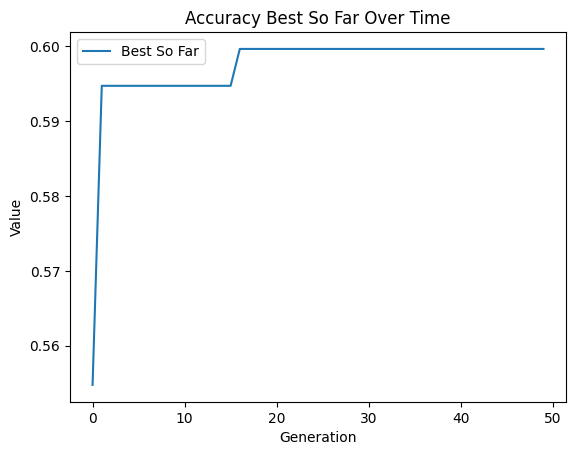

In [35]:
import json
import matplotlib.pyplot as plt

accs = []
evs = []
best_so_far = []  # 用來儲存每個世代中目前最好的值

# 設定要顯示的最大代數
max_generations = 50
# path_file = f"{path_out}/{start_day.strftime('%Y%m%d')}_{end_day.strftime('%Y%m%d')}_15pro/"
path_file = f"{path_out}/20230701_20240330/"

with open(f"{path_file}generation_results.json", 'r') as f:
    content = f.readlines()
    current_best = float('-inf')  # 初始化為最小值
    for i, line in enumerate(content):
        if i >= max_generations:  # 超過50代後停止
            break
        result = json.loads(line)
        acc = result['best_fitness']
        accs.append(acc)
        
        # 計算best so far
        if acc > current_best:
            current_best = acc
        best_so_far.append(current_best)

# 繪圖
# plt.plot(accs, label='Accuracy')
plt.plot(best_so_far, label='Best So Far')

plt.title('Accuracy Best So Far Over Time')  # 添加標題
plt.xlabel('Generation')  # X軸標籤
plt.ylabel('Value')  # Y軸標籤
plt.legend()  #


## 計算使用的費用